# DR2 Richness Weight Diagnostics

This notebook validates and visualizes the separate corrections stored in the unified DR2 redMaPPer--BGS matched catalog:

- `COMP_WEIGHT = 1 / PROB_OBS`: galaxy-level DESI completeness correction;
- `GEOMETRIC_WEIGHT = 1 / GEOMETRIC_FRACTION`: cluster-level aperture-coverage correction;
- `LF_WEIGHT`: cluster-level luminosity-function completeness correction; and
- `TOTAL_WEIGHT = COMP_WEIGHT * GEOMETRIC_WEIGHT * LF_WEIGHT`.

The notebook checks the weight identities, verifies that the geometric and luminosity-function terms are constant within each cluster, and examines their distributions and redshift dependence. Cluster-level quantities are plotted once per cluster so rich clusters do not receive extra visual weight.

In [1]:
from pathlib import Path
import pickle
import sys

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedFormatter, FixedLocator, NullFormatter
from astropy.table import Table, unique
from IPython.display import display

REPO_ROOT = Path('/global/homes/z/zzhang13/DESI/Projection')
if not REPO_ROOT.exists():
    REPO_ROOT = Path.cwd().resolve()
    if REPO_ROOT.name in {'richness_relation', 'tools', 'make_catalogs', 'plotting'}:
        REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

mpl.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.1,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': False,
})

CATALOG_PATH = REPO_ROOT / 'catalogs' / 'bgs_clus_RM_gal_matched_with_weights.pickle'
BCG_Z_RANGE = (0.10, 0.35)
OUTPUT_DIR = REPO_ROOT / 'plots' / 'weight_diagnostics'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Repository:', REPO_ROOT)
print('Catalog:', CATALOG_PATH)
print('Plots:', OUTPUT_DIR)

Repository: /global/homes/z/zzhang13/DESI/Projection
Catalog: /global/homes/z/zzhang13/DESI/Projection/catalogs/bgs_clus_RM_gal_matched_with_weights.pickle
Plots: /global/homes/z/zzhang13/DESI/Projection/plots/weight_diagnostics


In [2]:
def read_pickle_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Matched catalog not found: {path}')
    with path.open('rb') as handle:
        obj = pickle.load(handle)
    if isinstance(obj, Table):
        return obj
    if obj.__class__.__module__.startswith('pandas'):
        return Table.from_pandas(obj)
    if hasattr(obj, 'to_pandas'):
        return Table.from_pandas(obj.to_pandas())
    return Table(obj)


required_columns = [
    'ID',
    'Z_SPEC_central',
    'Z_BGS',
    'PROB_OBS',
    'COMP_WEIGHT',
    'GEOMETRIC_FRACTION',
    'GEOMETRIC_WEIGHT',
    'LF_WEIGHT',
    'TOTAL_WEIGHT',
]

bgs = read_pickle_table(CATALOG_PATH)
missing = [column for column in required_columns if column not in bgs.colnames]
if missing:
    raise KeyError(f'Missing required DR2 columns: {missing}')

n_rows_parent = len(bgs)
n_clusters_parent = len(np.unique(np.asarray(bgs['ID'], dtype=str)))
z_bcg = np.asarray(bgs['Z_SPEC_central'], dtype=float)
z_min, z_max = BCG_Z_RANGE
bcg_redshift_mask = (
    np.isfinite(z_bcg)
    & (z_bcg >= z_min)
    & (z_bcg < z_max)
)
bgs = bgs[bcg_redshift_mask]

print(f'BCG redshift selection: {z_min:.2f} <= z_BCG < {z_max:.2f}')
print(f'Rows: {n_rows_parent:,} -> {len(bgs):,}')
print(
    f'Clusters: {n_clusters_parent:,} -> '
    f'{len(np.unique(np.asarray(bgs["ID"], dtype=str))):,}'
)
print('All required DR2 weight columns are present.')

Rows: 400,252
Clusters: 10,419
All required DR2 weight columns are present.


## Internal consistency checks

These tests verify the definitions used by the matching pipeline. The relative differences should be consistent with floating-point precision, and the cluster-level weights should not vary among galaxies assigned to the same cluster.

In [3]:
def as_float(table, column):
    return np.asarray(table[column], dtype=float)


def relative_difference(measured, expected):
    measured = np.asarray(measured, dtype=float)
    expected = np.asarray(expected, dtype=float)
    scale = np.maximum(np.abs(expected), np.finfo(float).tiny)
    return np.abs(measured - expected) / scale


def clusters_with_variation(table, column):
    frame = pd.DataFrame({
        'ID': np.asarray(table['ID']).astype(str),
        column: as_float(table, column),
    })
    finite = np.isfinite(frame[column])
    n_unique = frame.loc[finite].groupby('ID')[column].nunique(dropna=True)
    return n_unique[n_unique > 1]


prob_obs = as_float(bgs, 'PROB_OBS')
comp_weight = as_float(bgs, 'COMP_WEIGHT')
geo_fraction = as_float(bgs, 'GEOMETRIC_FRACTION')
geo_weight = as_float(bgs, 'GEOMETRIC_WEIGHT')
lf_weight = as_float(bgs, 'LF_WEIGHT')
total_weight = as_float(bgs, 'TOTAL_WEIGHT')

with np.errstate(divide='ignore', invalid='ignore'):
    expected_comp = 1.0 / prob_obs
    expected_geo = 1.0 / geo_fraction
expected_total = comp_weight * geo_weight * lf_weight

checks = []
for name, measured, expected in [
    ('COMP_WEIGHT = 1 / PROB_OBS', comp_weight, expected_comp),
    ('GEOMETRIC_WEIGHT = 1 / GEOMETRIC_FRACTION', geo_weight, expected_geo),
    ('TOTAL_WEIGHT = component product', total_weight, expected_total),
]:
    valid_check = np.isfinite(measured) & np.isfinite(expected)
    delta = relative_difference(measured[valid_check], expected[valid_check])
    checks.append({
        'check': name,
        'N_tested': int(np.count_nonzero(valid_check)),
        'N_failed': int(np.count_nonzero(delta > 1e-10)),
        'max_relative_difference': np.nanmax(delta) if len(delta) else np.nan,
        'passed': bool(np.all(delta <= 1e-10)) if len(delta) else False,
    })

for column in ['GEOMETRIC_FRACTION', 'GEOMETRIC_WEIGHT', 'LF_WEIGHT']:
    varying = clusters_with_variation(bgs, column)
    checks.append({
        'check': f'{column} constant within cluster',
        'N_tested': len(np.unique(np.asarray(bgs['ID']).astype(str))),
        'N_failed': len(varying),
        'max_relative_difference': np.nan,
        'passed': len(varying) == 0,
    })

check_df = pd.DataFrame(checks)
display(check_df)

if not check_df['passed'].all():
    print('WARNING: At least one weight consistency test failed; inspect before using the catalog.')
else:
    print('All weight consistency tests passed.')

,check,N_tested,N_failed,max_relative_difference,passed
0,COMP_WEIGHT = 1 / PROB_OBS,398403,0,0.0,True
1,GEOMETRIC_WEIGHT = 1 / GEOMETRIC_FRACTION,400249,0,0.0,True
2,TOTAL_WEIGHT = component product,400252,0,0.0,True
3,GEOMETRIC_FRACTION constant within cluster,10419,0,NaN,True
4,GEOMETRIC_WEIGHT constant within cluster,10419,0,NaN,True
5,LF_WEIGHT constant within cluster,10419,0,NaN,True


All weight consistency tests passed.


## Weight summaries

`COMP_WEIGHT` and `TOTAL_WEIGHT` are summarized at the galaxy level. `GEOMETRIC_WEIGHT` and `LF_WEIGHT` are summarized once per cluster.

In [4]:
cluster_columns = [
    'ID',
    'Z_SPEC_central',
    'GEOMETRIC_FRACTION',
    'GEOMETRIC_WEIGHT',
    'LF_WEIGHT',
]
for optional_column in [
    'LAMBDA',
    'lambda_spec_proj',
    'lambda_spec_noproj',
    'lambda_spec_proj_weighted',
    'lambda_spec_noproj_weighted',
]:
    if optional_column in bgs.colnames:
        cluster_columns.append(optional_column)

clusters = unique(bgs[cluster_columns], keys='ID')
z_galaxy = as_float(bgs, 'Z_SPEC_central')
z_cluster = as_float(clusters, 'Z_SPEC_central')

weight_samples = {
    'completeness weight': {
        'values': comp_weight,
        'redshift': z_galaxy,
        'level': 'galaxy',
        'color': 'tab:blue',
    },
    'geometric weight': {
        'values': as_float(clusters, 'GEOMETRIC_WEIGHT'),
        'redshift': z_cluster,
        'level': 'cluster',
        'color': 'tab:orange',
    },
    'LF weight': {
        'values': as_float(clusters, 'LF_WEIGHT'),
        'redshift': z_cluster,
        'level': 'cluster',
        'color': 'tab:green',
    },
    'total weight': {
        'values': total_weight,
        'redshift': z_galaxy,
        'level': 'galaxy',
        'color': 'tab:red',
    },
}

summary_rows = []
for name, sample in weight_samples.items():
    values = sample['values']
    valid_values = np.isfinite(values) & (values > 0)
    selected = values[valid_values]
    summary_rows.append({
        'weight': name,
        'sampling': sample['level'],
        'N': len(selected),
        'minimum': np.nanmin(selected),
        'p16': np.nanpercentile(selected, 16),
        'median': np.nanmedian(selected),
        'p84': np.nanpercentile(selected, 84),
        'p95': np.nanpercentile(selected, 95),
        'p99': np.nanpercentile(selected, 99),
        'maximum': np.nanmax(selected),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,weight,sampling,N,minimum,p16,median,p84,p95,p99,maximum
0,completeness weight,galaxy,398403,1.000000,1.000000,1.153153,2.064516,3.368421,5.818182,128.000000
1,geometric weight,cluster,10418,0.934044,1.018752,1.064595,1.159148,1.380198,2.577235,227.112794
2,LF weight,cluster,10419,1.000000,3.071178,10.796969,26.451284,35.911423,40.874664,42.024156
3,total weight,galaxy,398403,1.012651,1.962428,5.903594,22.711268,42.167200,83.546248,2560.177314


## Weight distributions

In [9]:
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter

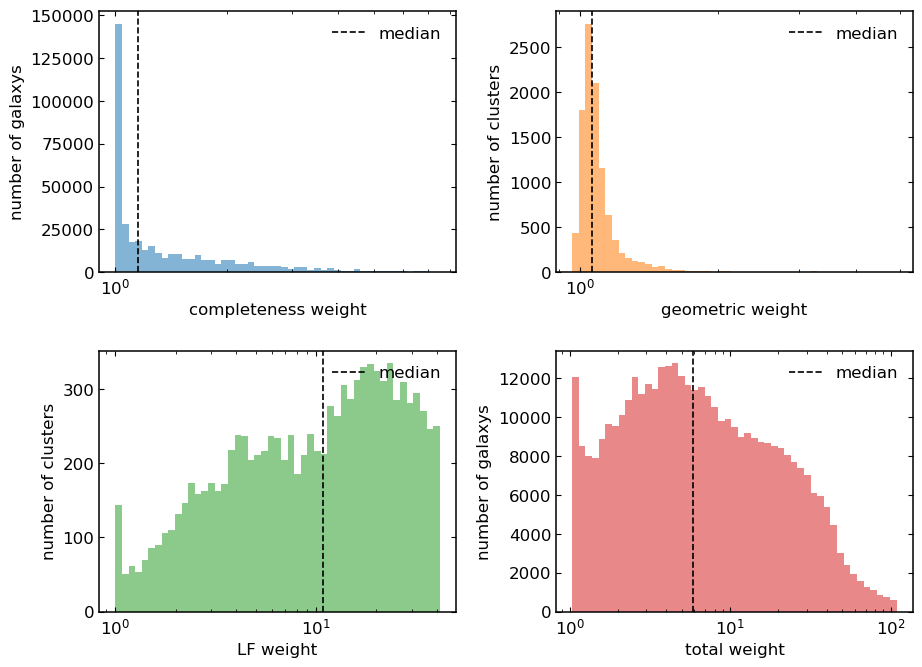

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.8))
axes = axes.ravel()

for ax, (name, sample) in zip(axes, weight_samples.items()):
    values = sample['values']
    values = values[np.isfinite(values) & (values > 0)]
    lower, upper = np.nanpercentile(values, [0.5, 99.5])
    lower = max(lower, np.finfo(float).tiny)
    if upper <= lower:
        upper = lower * 1.01
    bins = np.logspace(np.log10(lower), np.log10(upper), 50)
    ax.hist(values, bins=bins, histtype='stepfilled', alpha=0.55, color=sample['color'])
    ax.axvline(np.nanmedian(values), color='black', ls='--', lw=1.2, label='median')
    ax.set_xscale('log')
    candidate_ticks = [1, 2, 4, 8, 16, 32, 64, 128]
    xmin, xmax = ax.get_xlim()
    major_ticks = [tick for tick in candidate_ticks if xmin <= tick <= xmax]
    ax.xaxis.set_major_locator(FixedLocator(major_ticks))
    ax.xaxis.set_major_formatter(FixedFormatter([f'{tick:g}' for tick in major_ticks]))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='major', pad=6)
    ax.set_xlabel(name)
    ax.set_ylabel(f"number of {sample['level']}s")
    ax.legend(loc='upper right')
    ax.xaxis.set_minor_formatter(NullFormatter())

fig.subplots_adjust(wspace=0.28, hspace=0.30)
fig.savefig(OUTPUT_DIR / 'dr2_weight_component_histograms.png', dpi=180, bbox_inches='tight')
plt.show()

## Redshift dependence

Points show medians and shaded regions show the 16th--84th percentile intervals. The LF correction is expected to increase toward high redshift as progressively fewer faint galaxies remain observable.

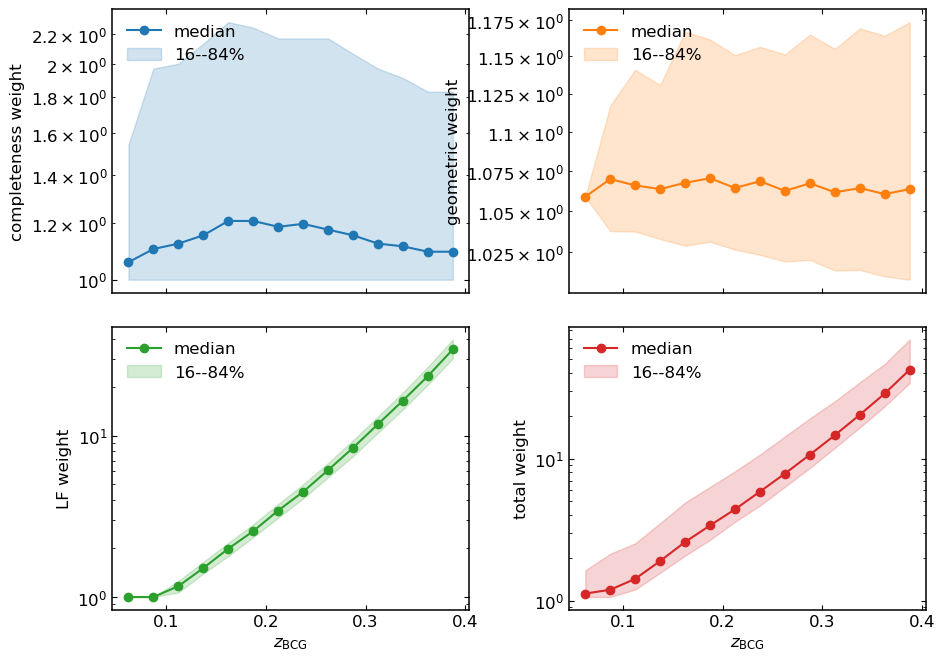

In [6]:
def binned_percentiles(x, y, bins):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    centers = 0.5 * (bins[:-1] + bins[1:])
    median = np.full(len(centers), np.nan)
    p16 = np.full(len(centers), np.nan)
    p84 = np.full(len(centers), np.nan)
    count = np.zeros(len(centers), dtype=int)
    for index, (lower, upper) in enumerate(zip(bins[:-1], bins[1:])):
        mask = (x >= lower) & (x < upper) & np.isfinite(y) & (y > 0)
        count[index] = np.count_nonzero(mask)
        if count[index] == 0:
            continue
        median[index] = np.nanmedian(y[mask])
        p16[index], p84[index] = np.nanpercentile(y[mask], [16, 84])
    return centers, median, p16, p84, count


z_bins = np.linspace(BCG_Z_RANGE[0], BCG_Z_RANGE[1], 11)
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.8), sharex=True)
axes = axes.ravel()

for ax, (name, sample) in zip(axes, weight_samples.items()):
    centers, median, p16, p84, count = binned_percentiles(
        sample['redshift'], sample['values'], z_bins
    )
    good = np.isfinite(median)
    ax.plot(centers[good], median[good], marker='o', color=sample['color'], label='median')
    ax.fill_between(
        centers[good], p16[good], p84[good],
        color=sample['color'], alpha=0.2, label='16--84%'
    )
    ax.set_yscale('log')
    ax.set_ylabel(name)
    ax.legend(loc='upper left')

for ax in axes[-2:]:
    ax.set_xlabel(r'$z_{\rm BCG}$')

fig.subplots_adjust(wspace=0.28, hspace=0.12)
fig.savefig(OUTPUT_DIR / 'dr2_weight_redshift_dependence.png', dpi=180, bbox_inches='tight')
plt.show()

## Total-weight composition

This view helps identify whether one component dominates the high-weight tail. All quantities here are shown at the galaxy level because `TOTAL_WEIGHT` includes the galaxy-specific completeness correction.

,log10 completeness,log10 geometric,log10 LF,log10 total,z_BCG
log10 completeness,1.000000,0.175912,-0.046202,0.354580,-0.040743
log10 geometric,0.175912,1.000000,-0.015751,0.137699,-0.015140
log10 LF,-0.046202,-0.015751,1.000000,0.913891,0.996740
log10 total,0.354580,0.137699,0.913891,1.000000,0.912991
z_BCG,-0.040743,-0.015140,0.996740,0.912991,1.000000


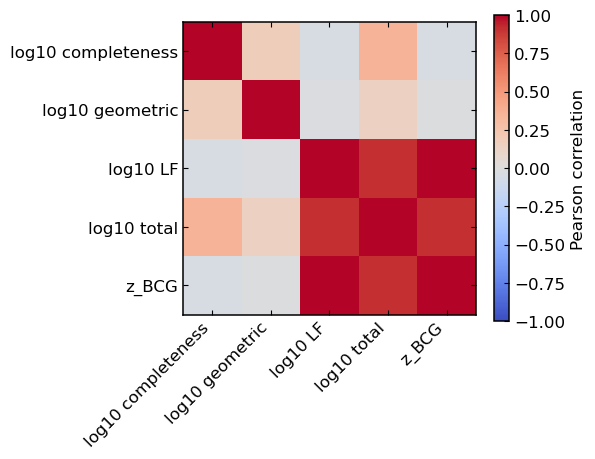

In [7]:
valid_components = (
    np.isfinite(comp_weight) & (comp_weight > 0)
    & np.isfinite(geo_weight) & (geo_weight > 0)
    & np.isfinite(lf_weight) & (lf_weight > 0)
    & np.isfinite(total_weight) & (total_weight > 0)
)

component_frame = pd.DataFrame({
    'log10 completeness': np.log10(comp_weight[valid_components]),
    'log10 geometric': np.log10(geo_weight[valid_components]),
    'log10 LF': np.log10(lf_weight[valid_components]),
    'log10 total': np.log10(total_weight[valid_components]),
    'z_BCG': z_galaxy[valid_components],
})

display(component_frame.corr())

fig, ax = plt.subplots(figsize=(6.1, 5.1))
correlation = component_frame.corr()
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(np.arange(len(correlation.columns)))
ax.set_yticks(np.arange(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation.columns)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label('Pearson correlation')
fig.subplots_adjust(left=0.28, bottom=0.28, right=0.88)
fig.savefig(OUTPUT_DIR / 'dr2_weight_log_correlation_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

## Spectroscopic-richness response

When the matching script has appended richness columns, this diagnostic compares continuum-subtracted richness before and after application of `TOTAL_WEIGHT`. The second panel shows whether the fractional boost follows the expected redshift dependence.

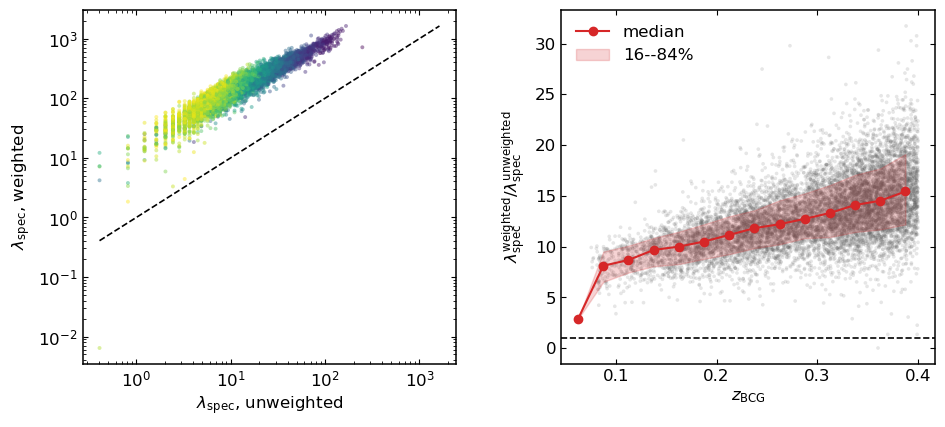

Clusters in richness comparison: 10,400
Richness-boost percentiles: [1.58152454e-02 9.91140646e+00 1.26664259e+01 1.62028330e+01
 3.17377095e+01]


In [8]:
unweighted_column = 'lambda_spec_noproj'
weighted_column = 'lambda_spec_noproj_weighted'

if unweighted_column not in clusters.colnames or weighted_column not in clusters.colnames:
    print('Richness columns are absent; skipping the weighted-richness diagnostic.')
else:
    richness_unweighted = as_float(clusters, unweighted_column)
    richness_weighted = as_float(clusters, weighted_column)
    valid_richness = (
        np.isfinite(richness_unweighted)
        & np.isfinite(richness_weighted)
        & (richness_unweighted > 0)
        & (richness_weighted > 0)
    )
    boost = richness_weighted[valid_richness] / richness_unweighted[valid_richness]

    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))

    axes[0].scatter(
        richness_unweighted[valid_richness],
        richness_weighted[valid_richness],
        c=z_cluster[valid_richness],
        s=8,
        alpha=0.45,
        cmap='viridis',
        edgecolor='none',
        rasterized=True,
    )
    lower = np.nanmin(richness_unweighted[valid_richness])
    upper = np.nanmax(np.concatenate([
        richness_unweighted[valid_richness],
        richness_weighted[valid_richness],
    ]))
    axes[0].plot([lower, upper], [lower, upper], color='black', ls='--', lw=1.2)
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel(r'$\lambda_{\rm spec}$, unweighted')
    axes[0].set_ylabel(r'$\lambda_{\rm spec}$, weighted')

    centers, median, p16, p84, count = binned_percentiles(
        z_cluster[valid_richness], boost, z_bins
    )
    good = np.isfinite(median)
    axes[1].scatter(
        z_cluster[valid_richness], boost,
        s=7, alpha=0.15, color='0.35', edgecolor='none', rasterized=True
    )
    axes[1].plot(centers[good], median[good], marker='o', color='tab:red', label='median')
    axes[1].fill_between(
        centers[good], p16[good], p84[good], color='tab:red', alpha=0.2, label='16--84%'
    )
    axes[1].axhline(1.0, color='black', ls='--', lw=1.2)
    axes[1].set_xlabel(r'$z_{\rm BCG}$')
    axes[1].set_ylabel(r'$\lambda_{\rm spec}^{\rm weighted}/\lambda_{\rm spec}^{\rm unweighted}$')
    axes[1].legend(loc='upper left')

    fig.subplots_adjust(wspace=0.28)
    fig.savefig(OUTPUT_DIR / 'dr2_weighted_vs_unweighted_richness.png', dpi=180, bbox_inches='tight')
    plt.show()

    print(f'Clusters in richness comparison: {np.count_nonzero(valid_richness):,}')
    print('Richness-boost percentiles:', np.nanpercentile(boost, [0, 16, 50, 84, 100]))